In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [7]:
from pipeline.test import make_model

# 1. 데이터 불러오기
df = pd.read_csv('./result/C_AB_VIF_col_17_with_segment.csv')

# 2. C, A, B만 추출
df_ab_c = df[df['Segment'].isin(['A', 'B', 'C'])].copy()

# 3. 타겟 생성: C=0, A/B=1
df_ab_c['target'] = (df_ab_c['Segment'].isin(['A', 'B'])).astype(int)

# 4. 피처/타겟 분리
drop_cols = ['ID', 'Segment', 'target']
feature_names = df_ab_c.drop(columns=drop_cols).columns.tolist()
X = df_ab_c.drop(columns=drop_cols).values
y = df_ab_c['target'].values

# 5. 모델 학습
model, results = make_model(X, y, cv=10, file_name="Segment_C_vs_AB")

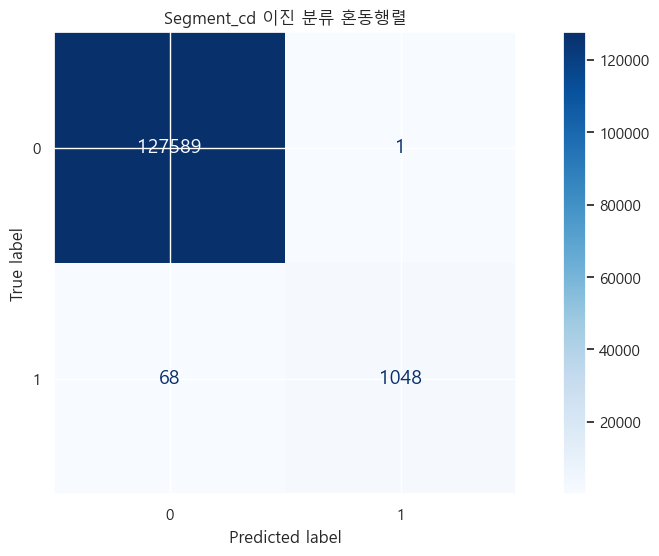

Classification Report
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997    127590
           1     0.9990    0.9391    0.9681      1116

    accuracy                         0.9995    128706
   macro avg     0.9993    0.9695    0.9839    128706
weighted avg     0.9995    0.9995    0.9995    128706



In [8]:
# XGBoost Booster 로드
model = xgb.Booster()
model.load_model('./model/Segment_C_vs_AB_Classifier_final.json')

# DMatrix 변환 및 예측
dtest = xgb.DMatrix(X)
y_prob = model.predict(dtest)
y_pred = (y_prob >= 0.5).astype(int)

# 혼동행렬
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Segment_cd 이진 분류 혼동행렬")
plt.show()

# 정밀도/재현율/F1 점수
print("Classification Report")
print(classification_report(y, y_pred, digits=4))

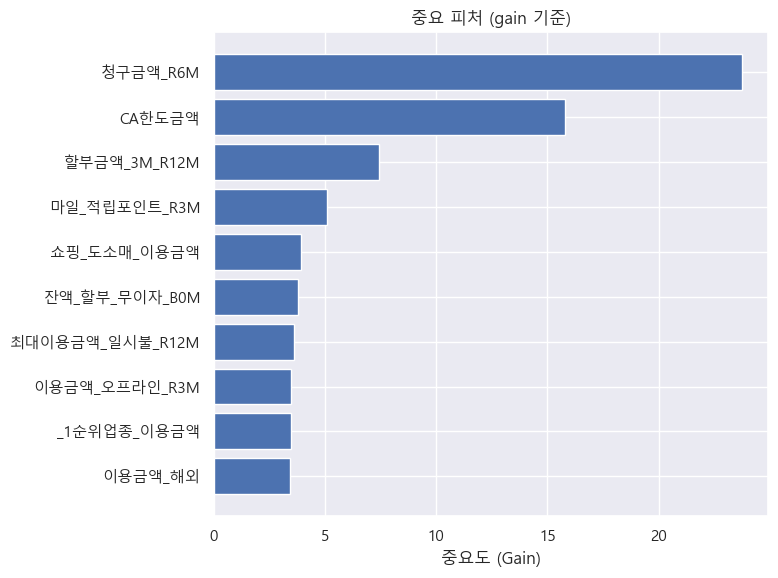

In [9]:
# 중요도 딕셔너리 얻기
importance_dict = model.get_score(importance_type='gain')

# f0, f1, ... 을 실제 컬럼명으로 변환
feature_map = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_named = {feature_map[k]: v for k, v in importance_dict.items()}

# 시각화
import matplotlib.pyplot as plt

sorted_items = sorted(importance_named.items(), key=lambda x: x[1], reverse=True)[:10]
names, scores = zip(*sorted_items)

plt.figure(figsize=(8, 6))
plt.barh(names[::-1], scores[::-1])  # 상위 피처부터 위로
plt.title("중요 피처 (gain 기준)")
plt.xlabel("중요도 (Gain)")
plt.tight_layout()
plt.show()

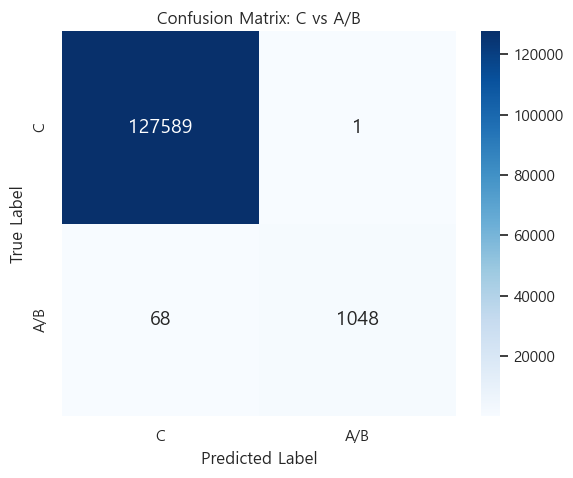

In [12]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DMatrix로 변환
dmat = xgb.DMatrix(X, feature_names=feature_names)

# 2. 예측
y_pred = model.predict(dmat)
y_pred = (y_pred > 0.5).astype(int)  # 확률 → 이진값 변환

# 3. 혼동 행렬
cm = confusion_matrix(y, y_pred)

# 4. 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['C', 'A/B'], yticklabels=['C', 'A/B'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: C vs A/B')
plt.tight_layout()
plt.show()

#### SHAP

In [14]:
import sys
print(sys.executable)

c:\Users\COTTA\anaconda3\python.exe


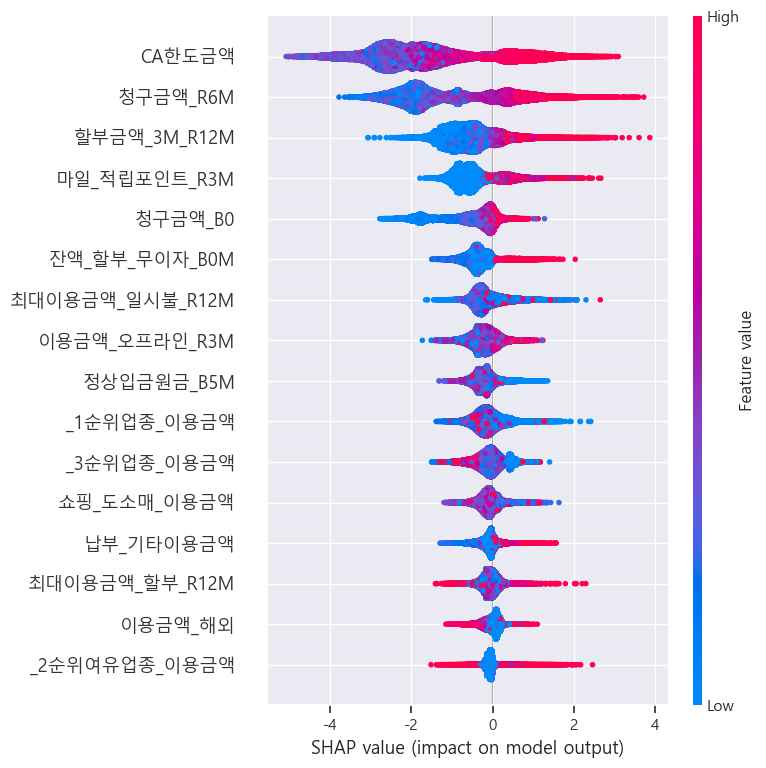

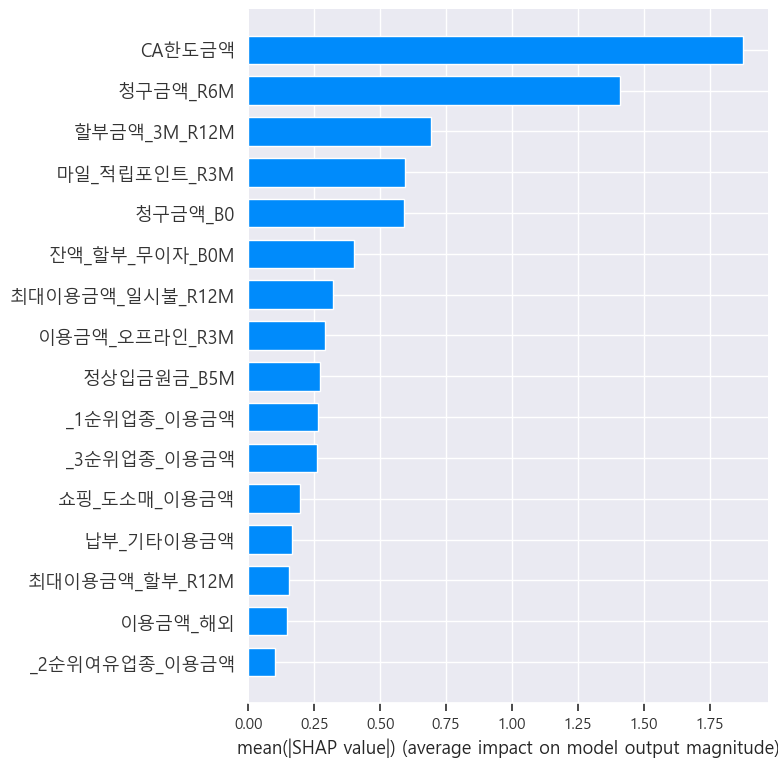

In [15]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# SHAP 계산을 위한 TreeExplainer 생성
explainer = shap.TreeExplainer(model)  # model은 XGBClassifier 객체

# SHAP 값 계산
shap_values = explainer.shap_values(X)

# 1. 전체 Feature 영향도 시각화 (summary plot)
shap.summary_plot(shap_values, X, feature_names=feature_names)

# 2. 각 피처의 평균 영향력 (bar plot)
shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type='bar')

#### 주성분 검사

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 18 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   ID               object
 1   CA한도금액           int64 
 2   _3순위업종_이용금액      int64 
 3   정상입금원금_B5M       int64 
 4   할부금액_3M_R12M     int64 
 5   최대이용금액_일시불_R12M  int64 
 6   납부_기타이용금액        int64 
 7   이용금액_해외          int64 
 8   이용금액_오프라인_R3M    int64 
 9   최대이용금액_할부_R12M   int64 
 10  쇼핑_도소매_이용금액      int64 
 11  _2순위여유업종_이용금액    int64 
 12  _1순위업종_이용금액      int64 
 13  청구금액_R6M         int64 
 14  청구금액_B0          int64 
 15  마일_적립포인트_R3M     int64 
 16  잔액_할부_무이자_B0M    int64 
 17  Segment          object
dtypes: int64(16), object(2)
memory usage: 329.6+ MB


In [29]:
df['target'] = (df['Segment'].isin(['A', 'B'])).astype(int)

X = df.drop(columns=['ID', 'Segment', 'target']).values
y = df['target'].values

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

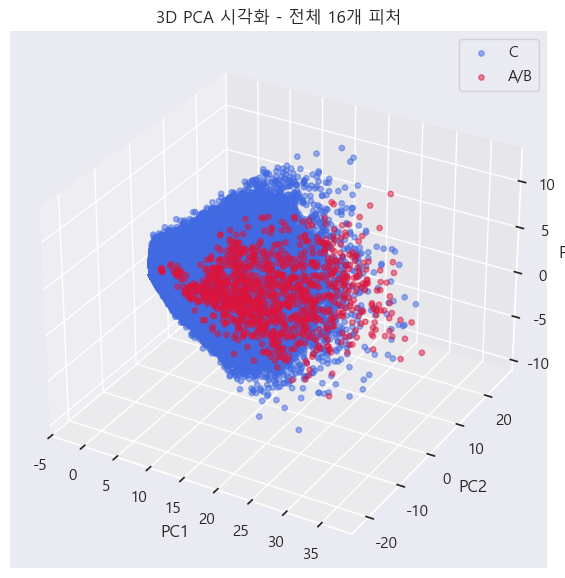

In [31]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

colors = ['royalblue', 'crimson']
labels = ['C', 'A/B']

for class_value in [0, 1]:
    idx = (y == class_value)
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        X_pca[idx, 2],
        label=labels[class_value],
        alpha=0.5,
        s=15,
        c=colors[class_value]
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA 시각화 - 전체 16개 피처")
ax.legend()
plt.tight_layout()
plt.show()


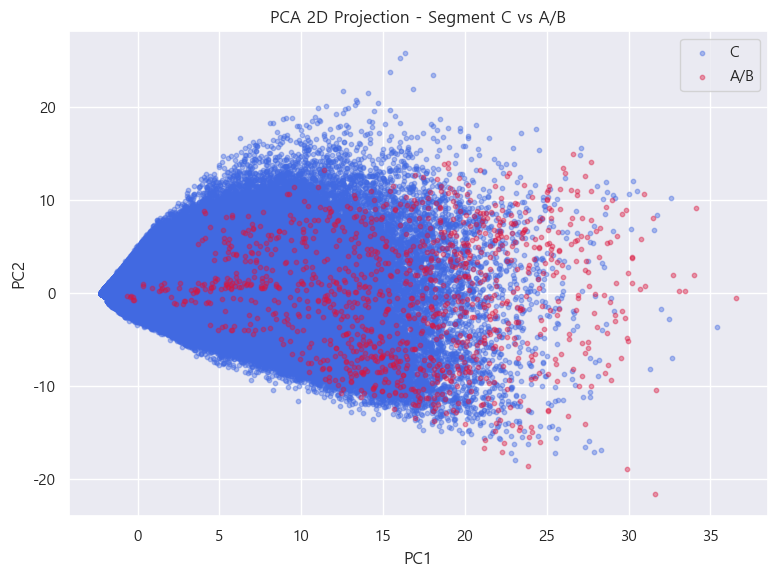

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. target 생성: C=0, A/B=1
df['target'] = (df['Segment'].isin(['A', 'B'])).astype(int)

# 2. 입력 피처만 추출 (ID, Segment, target 제외)
X = df.drop(columns=['ID', 'Segment', 'target']).values
y = df['target'].values

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA 2차원 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.4, label='C', s=10, c='royalblue')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.4, label='A/B', s=10, c='crimson')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Projection - Segment C vs A/B')
plt.legend()
plt.tight_layout()
plt.show()


#### 상위 n개 피처

In [16]:
top_features = [
    'CA한도금액',
    '청구금액_R6M',
    '할부금액_3M_R12M',
    '마일_적립포인트_R3M',
    '청구금액_B0'
]

In [17]:
X_top = df_ab_c[top_features].values
y_top = df_ab_c['target'].values

model_top, results_top = make_model(X_top, y_top, cv=10, file_name="Segment_C_vs_AB_TOP5")

In [21]:
from sklearn.metrics import classification_report

# 전체 데이터에 대해 예측
y_pred_top = model_top.predict(X_top)

# classification_report 출력
print(classification_report(y_top, y_pred_top, target_names=["C", "A/B"], digits=4))

              precision    recall  f1-score   support

           C     0.9948    0.9998    0.9973    127590
         A/B     0.9458    0.4068    0.5689      1116

    accuracy                         0.9947    128706
   macro avg     0.9703    0.7033    0.7831    128706
weighted avg     0.9944    0.9947    0.9936    128706



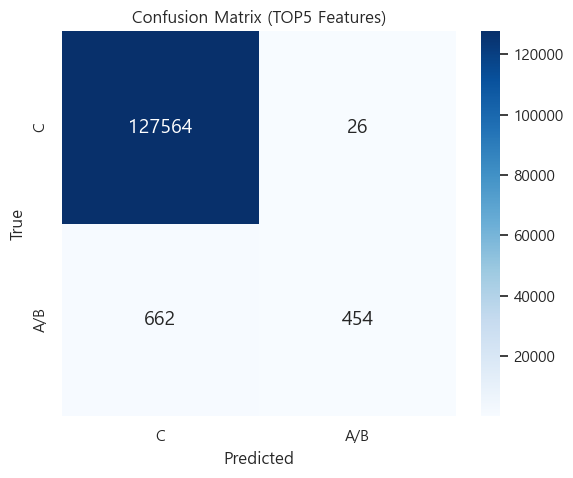

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 데이터에 대해 예측
y_pred_top = model_top.predict(X_top)

# 혼동행렬
cm = confusion_matrix(y_top, y_pred_top)

# 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['C', 'A/B'], yticklabels=['C', 'A/B'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (TOP5 Features)")
plt.tight_layout()
plt.show()


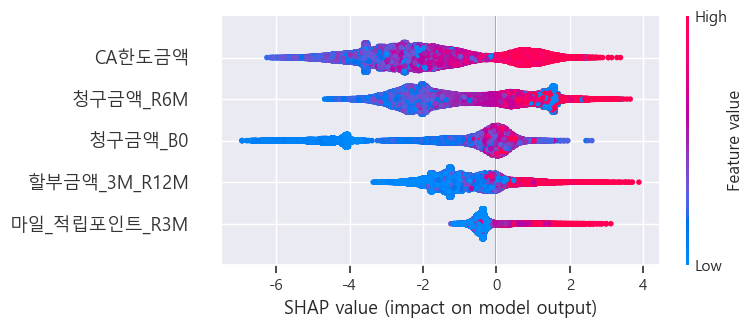

In [20]:
import shap

# 모델에 SHAP explainer 적용
explainer = shap.Explainer(model_top)
shap_values = explainer(X_top)

# Summary plot
shap.summary_plot(shap_values, features=X_top, feature_names=top_features)


In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from pipeline.test import make_model

# 1. 중요도 불러오기
df = pd.read_csv('./result/C_AB_VIF_col_17_with_segment.csv')
importance_dict = model.get_score(importance_type='gain')
feature_map = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_named = {feature_map[k]: v for k, v in importance_dict.items()}
sorted_items = sorted(importance_named.items(), key=lambda x: x[1], reverse=True)

# 2. 반복 실험
for top_n in [5, 7, 10, 12, 15]:
    print(f"\n🧪 실험 시작: 상위 {top_n}개 피처")
    
    # 3. 피처 선택
    top_features = [name for name, _ in sorted_items[:top_n]]
    
    # 4. 데이터셋 재구성
    df_ab_c = df[df['Segment'].isin(['A', 'B', 'C'])].copy()
    df_ab_c['target'] = (df_ab_c['Segment'].isin(['A', 'B'])).astype(int)
    
    X = df_ab_c[top_features].values
    y = df_ab_c['target'].values
    
    # 5. 학습
    model, results = make_model(X, y, cv=10, file_name=f"Segment_C_vs_AB_top{top_n}")
    
    # 6. 전체 성능 평가
    from sklearn.metrics import classification_report
    y_pred = model.predict(X)
    print(classification_report(y, y_pred, target_names=['C', 'A/B']))



🧪 실험 시작: 상위 5개 피처
              precision    recall  f1-score   support

           C       1.00      1.00      1.00    127590
         A/B       0.95      0.51      0.66      1116

    accuracy                           1.00    128706
   macro avg       0.98      0.75      0.83    128706
weighted avg       1.00      1.00      0.99    128706


🧪 실험 시작: 상위 7개 피처
              precision    recall  f1-score   support

           C       1.00      1.00      1.00    127590
         A/B       0.99      0.69      0.81      1116

    accuracy                           1.00    128706
   macro avg       0.99      0.85      0.91    128706
weighted avg       1.00      1.00      1.00    128706


🧪 실험 시작: 상위 10개 피처
              precision    recall  f1-score   support

           C       1.00      1.00      1.00    127590
         A/B       1.00      0.85      0.92      1116

    accuracy                           1.00    128706
   macro avg       1.00      0.92      0.96    128706
weighted avg    